In [3]:
import numpy as np

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt

fits_path = "2026-01-22__23-58-27_VisSci_55CNC_d1280_n001_f00100_e000200000us.fits"

# Use memmap=False because this file uses BZERO/BSCALE
hdul = fits.open(fits_path, memmap=False)
hdul.info()

Filename: 2026-01-22__23-58-27_VisSci_55CNC_d1280_n001_f00100_e000200000us.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   ()      
  1  SCIENCE       1 ImageHDU        14   (1282, 1282, 10)   int32 (rescales to uint32)   
  2  ROITABLE      1 TableHDU        17   1R x 2C   [I21, I21]   
  3  TEMP_TIME     1 TableHDU        15   100R x 2C   [I194, D25.17]   
  4  ASTROMETRY    1 TableHDU        18   100R x 3C   [D25.17, D25.17, D25.17]   


Data shape: (10, 1282, 1282)
Data dtype: uint32
NAXIS: 3
NAXIS1: 1282, NAXIS2: 1282, NAXIS3: 10
Min/Max (finite): 0 655350
Mean/Std (finite): 1173.5485860261244 3898.355774856726


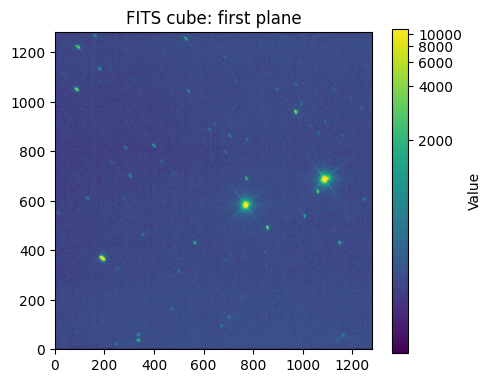

In [25]:
# Find first HDU with data
hdu_with_data = next((hdu for hdu in hdul if getattr(hdu, "data", None) is not None), None)

if hdu_with_data is None:
    raise ValueError("No data found in any HDU.")

data = hdu_with_data.data
header = hdu_with_data.header

print(f"Data shape: {data.shape}")
print(f"Data dtype: {data.dtype}")
print(f"NAXIS: {header.get('NAXIS')}")
print(f"NAXIS1: {header.get('NAXIS1')}, NAXIS2: {header.get('NAXIS2')}, NAXIS3: {header.get('NAXIS3')}")

# Basic stats (ignore NaNs)
finite = np.isfinite(data)
print("Min/Max (finite):", np.nanmin(data[finite]), np.nanmax(data[finite]))
print("Mean/Std (finite):", np.nanmean(data[finite]), np.nanstd(data[finite]))

data_shift = roi_cube - np.nanmin(data) + 1e-3
norm = ImageNormalize(data_shift, interval=ZScaleInterval(contrast=0.1), stretch=LogStretch(a=1000))

# Quick-look visualization for 2D/3D data cubes
if data.ndim == 2:
    plt.figure(figsize=(5, 4))
    plt.imshow(data, origin="lower", cmap="viridis", norm=norm)
    plt.colorbar(label="Value")
    plt.title("FITS image")
    plt.tight_layout()
elif data.ndim >= 3:
    plane0 = data[0]
    plt.figure(figsize=(5, 4))
    plt.imshow(plane0, origin="lower", cmap="viridis", norm=norm)
    plt.colorbar(label="Value")
    plt.title("FITS cube: first plane")
    plt.tight_layout()

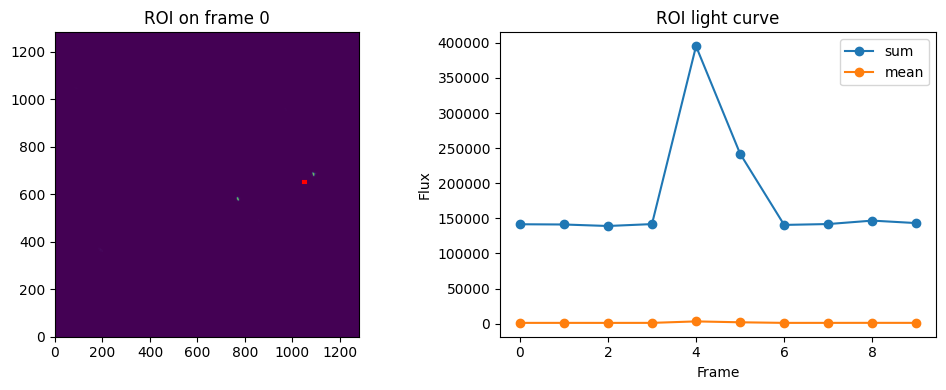

In [ ]:
# ROI light-curve extraction
# Set ROI center (y, x) and half-size in pixels
roi_center = (650, 1050)  # <-- adjust as needed
roi_half_size = 5         # ROI will be (2*half_size+1)^2

if data.ndim != 3:
    raise ValueError("Expected 3D data cube (t, y, x).")

n_frames, ny, nx = data.shape
cy, cx = roi_center

# Clip ROI bounds to image
y1 = max(cy - roi_half_size, 0)
y2 = min(cy + roi_half_size + 1, ny)
x1 = max(cx - roi_half_size, 0)
x2 = min(cx + roi_half_size + 1, nx)

roi = data[:, y1:y2, x1:x2]

norm = ImageNormalize(roi, interval=ZScaleInterval(contrast=0.001), stretch=LogStretch(a=1000))

# Sum and mean light curves
lc_sum = roi.sum(axis=(1, 2))
lc_mean = roi.mean(axis=(1, 2))

# Plot ROI on first frame and the light curve
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(data[0], origin="lower", cmap="viridis")
ax[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              edgecolor="red", facecolor="none", linewidth=1.5))
ax[0].set_title("ROI on frame 0")

ax[1].plot(lc_sum, marker="o", label="sum")
ax[1].plot(lc_mean, marker="o", label="mean")
ax[1].set_xlabel("Frame")
ax[1].set_ylabel("Flux")
ax[1].legend()
ax[1].set_title("ROI light curve")

plt.tight_layout()

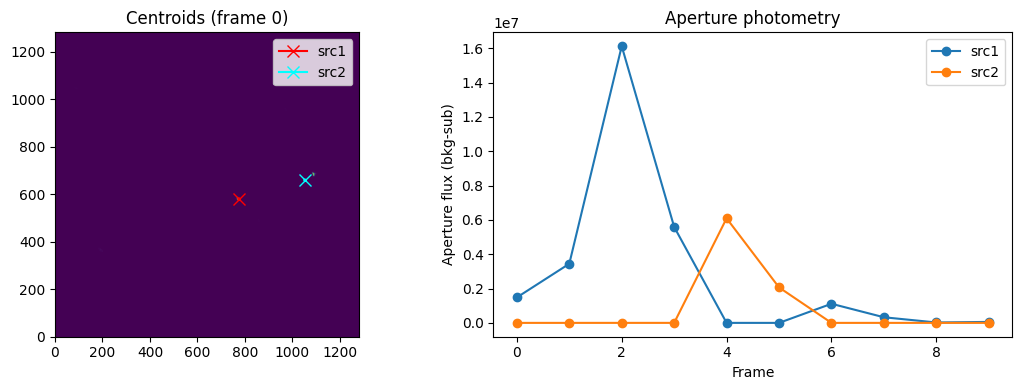

In [7]:
# Centroids + simple aperture photometry for two sources
# Provide seed positions (y, x) from frame 0
seeds = [(580, 780), (660, 1050)]  # <-- adjust as needed

ap_radius = 4.0
annulus_r_in = 6.0
annulus_r_out = 9.0

if data.ndim != 3:
    raise ValueError("Expected 3D data cube (t, y, x).")

n_frames, ny, nx = data.shape

Y, X = np.mgrid[0:ny, 0:nx]

def centroid_in_box(img, yx, half_size=6):
    cy, cx = yx
    y1 = max(cy - half_size, 0)
    y2 = min(cy + half_size + 1, ny)
    x1 = max(cx - half_size, 0)
    x2 = min(cx + half_size + 1, nx)
    sub = img[y1:y2, x1:x2]
    ysub, xsub = np.mgrid[y1:y2, x1:x2]
    # subtract local median to reduce background bias
    w = sub - np.median(sub)
    w[w < 0] = 0
    if np.sum(w) == 0:
        return float(cy), float(cx)
    ycen = np.sum(ysub * w) / np.sum(w)
    xcen = np.sum(xsub * w) / np.sum(w)
    return ycen, xcen

def aperture_photometry(img, yx, r, r_in, r_out):
    cy, cx = yx
    rr = np.hypot(X - cx, Y - cy)
    aper_mask = rr <= r
    ann_mask = (rr >= r_in) & (rr <= r_out)
    if not np.any(ann_mask):
        raise ValueError("Annulus mask is empty; adjust radii.")
    bkg = np.median(img[ann_mask])
    flux = np.sum(img[aper_mask] - bkg)
    return flux, bkg

centroids = {i: [] for i in range(len(seeds))}
fluxes = {i: [] for i in range(len(seeds))}

for t in range(n_frames):
    img = data[t]
    for i, seed in enumerate(seeds):
        yc, xc = centroid_in_box(img, seed, half_size=6)
        centroids[i].append((yc, xc))
        f, b = aperture_photometry(img, (yc, xc), ap_radius, annulus_r_in, annulus_r_out)
        fluxes[i].append(f)

# Plot centroids on frame 0 and light curves
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(data[0], origin="lower", cmap="viridis")
colors = ["red", "cyan"]
for i in range(len(seeds)):
    yc0, xc0 = centroids[i][0]
    ax[0].plot(xc0, yc0, marker="x", color=colors[i], markersize=8, label=f"src{i+1}")
    circ = plt.Circle((xc0, yc0), ap_radius, edgecolor=colors[i], facecolor="none", linewidth=1)
    ax[0].add_patch(circ)
ax[0].set_title("Centroids (frame 0)")
ax[0].legend()

for i in range(len(seeds)):
    ax[1].plot(fluxes[i], marker="o", label=f"src{i+1}")
ax[1].set_xlabel("Frame")
ax[1].set_ylabel("Aperture flux (bkg-sub)")
ax[1].set_title("Aperture photometry")
ax[1].legend()

plt.tight_layout()

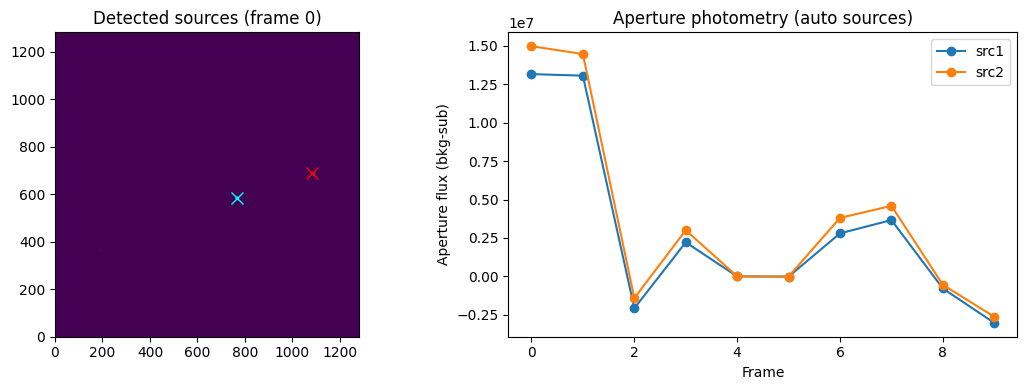

In [6]:
# Auto-detect sources (photutils) and run simple aperture photometry
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

frame0 = data[0].astype(float)
mean, median, std = sigma_clipped_stats(frame0, sigma=3.0)

finder = DAOStarFinder(fwhm=3.0, threshold=5.0 * std)
sources = finder(frame0 - median)

if sources is None or len(sources) == 0:
    raise ValueError("No sources found. Try lowering threshold or adjusting FWHM.")

# Sort by peak flux and take the two brightest
sources.sort("flux")
sources = sources[::-1]
xy = [(sources["xcentroid"][0], sources["ycentroid"][0]),
      (sources["xcentroid"][1], sources["ycentroid"][1])]

ap_r = 4.0
ann_r_in = 6.0
ann_r_out = 9.0

# Plot detections on frame 0
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(frame0, origin="lower", cmap="viridis")
for i, (x, y) in enumerate(xy):
    ax[0].plot(x, y, marker="x", color=("red" if i == 0 else "cyan"), markersize=8)
    ax[0].add_patch(plt.Circle((x, y), ap_r, edgecolor=("red" if i == 0 else "cyan"),
                               facecolor="none", linewidth=1))
ax[0].set_title("Detected sources (frame 0)")

# Fixed-position aperture photometry across frames
n_frames = data.shape[0]
fluxes_auto = [[], []]
for t in range(n_frames):
    img = data[t].astype(float)
    apertures = CircularAperture(xy, r=ap_r)
    annulus = CircularAnnulus(xy, r_in=ann_r_in, r_out=ann_r_out)
    aper_table = aperture_photometry(img, apertures)
    ann_table = aperture_photometry(img, annulus)

    annulus_area = annulus.area
    bkg_mean = ann_table["aperture_sum"] / annulus_area
    bkg_sum = bkg_mean * apertures.area
    net_flux = aper_table["aperture_sum"] - bkg_sum

    fluxes_auto[0].append(net_flux[0])
    fluxes_auto[1].append(net_flux[1])

ax[1].plot(fluxes_auto[0], marker="o", label="src1")
ax[1].plot(fluxes_auto[1], marker="o", label="src2")
ax[1].set_xlabel("Frame")
ax[1].set_ylabel("Aperture flux (bkg-sub)")
ax[1].set_title("Aperture photometry (auto sources)")
ax[1].legend()

plt.tight_layout()

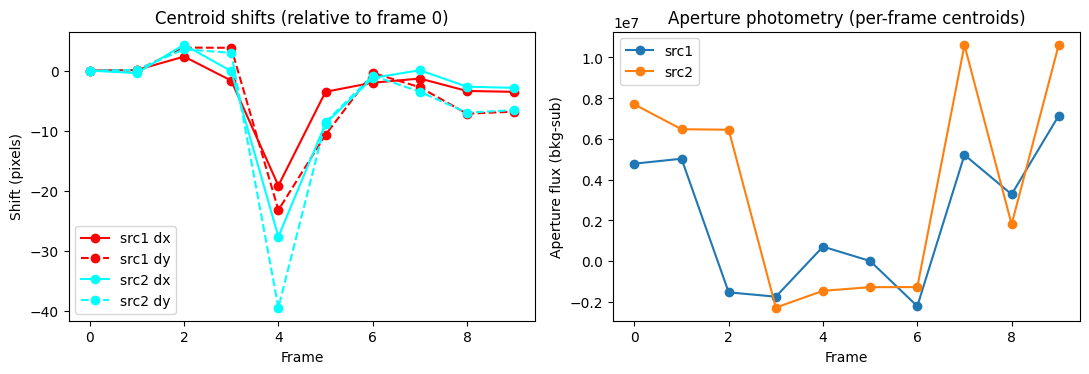

In [12]:
# Refine centroids per frame and re-run aperture photometry
from photutils.centroids import centroid_com, centroid_2dg

box_half = 6  # half-size of centroiding box (pixels)

centroids_pf = [[], []]
fluxes_pf = [[], []]

for t in range(n_frames):
    img = data[t].astype(float)
    refined_xy = []
    for i, (x0, y0) in enumerate(xy):
        x0 = int(round(x0))
        y0 = int(round(y0))
        x1 = max(x0 - box_half, 0)
        x2 = min(x0 + box_half + 1, img.shape[1])
        y1 = max(y0 - box_half, 0)
        y2 = min(y0 + box_half + 1, img.shape[0])

        cut = img[y1:y2, x1:x2]
        # subtract local median to reduce background bias
        cut = cut - np.median(cut)
        cut[cut < 0] = 0

        # Use 2D Gaussian centroid; fall back to COM, then peak
        try:
            yc, xc = centroid_2dg(cut)
            if not np.isfinite(xc) or not np.isfinite(yc):
                raise ValueError("NaN centroid")
        except Exception:
            try:
                yc, xc = centroid_com(cut)
            except Exception:
                py, px = np.unravel_index(np.argmax(cut), cut.shape)
                yc, xc = float(py), float(px)

        # shift centroid back to full-image coords
        xc += x1
        yc += y1

        refined_xy.append((xc, yc))
        centroids_pf[i].append((xc, yc))

    apertures = CircularAperture(refined_xy, r=ap_r)
    annulus = CircularAnnulus(refined_xy, r_in=ann_r_in, r_out=ann_r_out)
    aper_table = aperture_photometry(img, apertures)
    ann_table = aperture_photometry(img, annulus)

    annulus_area = annulus.area
    bkg_mean = ann_table["aperture_sum"] / annulus_area
    bkg_sum = bkg_mean * apertures.area
    net_flux = aper_table["aperture_sum"] - bkg_sum

    fluxes_pf[0].append(net_flux[0])
    fluxes_pf[1].append(net_flux[1])

# Plot centroid shifts and updated photometry
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for i, color in enumerate(["red", "cyan"]):
    x0, y0 = centroids_pf[i][0]
    dx = [c[0] - x0 for c in centroids_pf[i]]
    dy = [c[1] - y0 for c in centroids_pf[i]]
    ax[0].plot(dx, marker="o", color=color, label=f"src{i+1} dx")
    ax[0].plot(dy, marker="o", linestyle="--", color=color, label=f"src{i+1} dy")

ax[0].set_xlabel("Frame")
ax[0].set_ylabel("Shift (pixels)")
ax[0].set_title("Centroid shifts (relative to frame 0)")
ax[0].legend()

ax[1].plot(fluxes_pf[0], marker="o", label="src1")
ax[1].plot(fluxes_pf[1], marker="o", label="src2")
ax[1].set_xlabel("Frame")
ax[1].set_ylabel("Aperture flux (bkg-sub)")
ax[1].set_title("Aperture photometry (per-frame centroids)")
ax[1].legend()

plt.tight_layout()

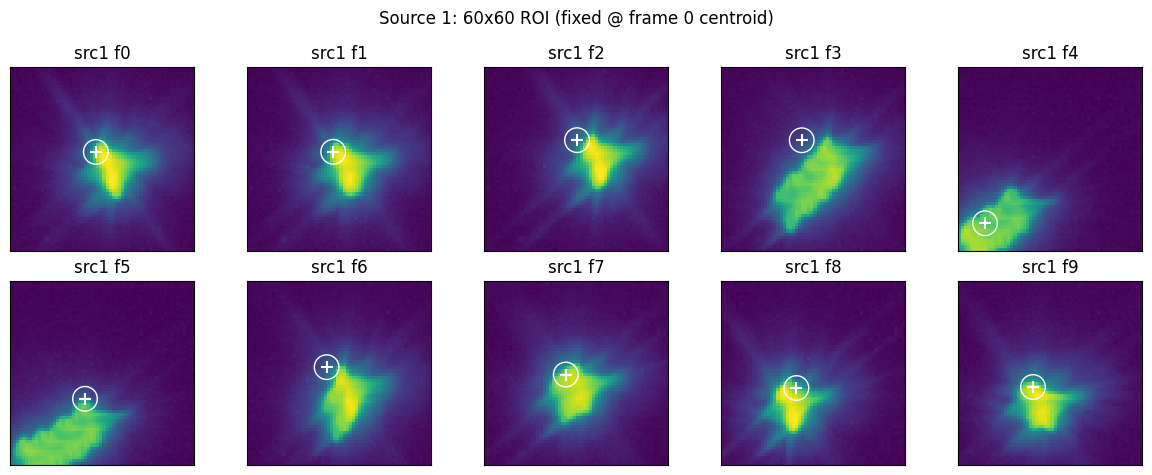

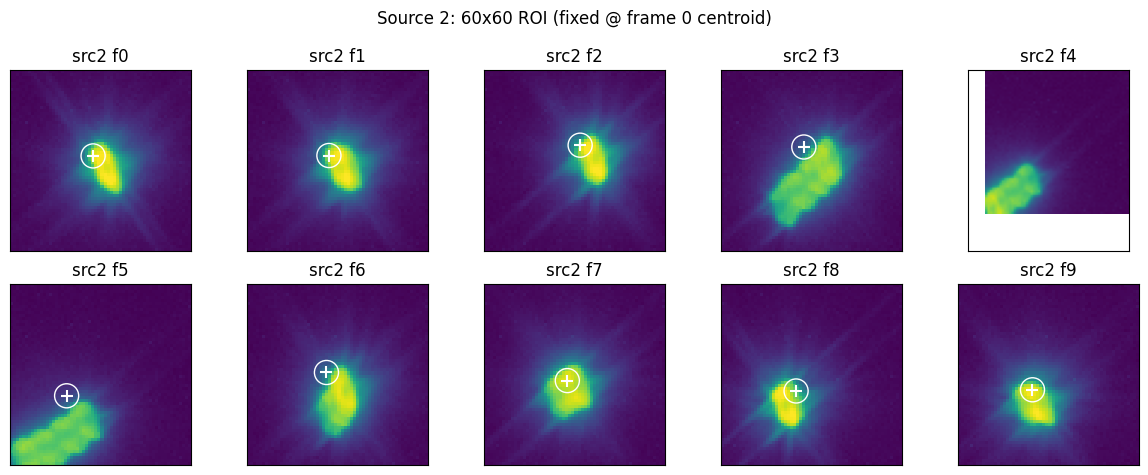

In [22]:
# Plot 20x20 ROI grid for each source using initial centroid positions
from astropy.visualization import ImageNormalize, ZScaleInterval, LogStretch

roi_size = 60
half = roi_size // 2

init_xy = xy  # initial centroids from auto-detection (x, y)

for si, (x0, y0) in enumerate(init_xy):
    x0 = int(round(x0))
    y0 = int(round(y0))
    x1 = max(x0 - half, 0)
    x2 = min(x0 + half, data.shape[2])
    y1 = max(y0 - half, 0)
    y2 = min(y0 + half, data.shape[1])

    # Build ROI cube for this source
    roi_cube = data[:, y1:y2, x1:x2].astype(float)
    roi_cube_shift = roi_cube - np.nanmin(roi_cube) + 1e-3
    norm = ImageNormalize(roi_cube_shift, interval=ZScaleInterval(contrast=0.001), stretch=LogStretch(a=1000))

    # Plot frames in a grid
    ncols = 5
    nrows = int(np.ceil(n_frames / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.4 * nrows))
    axes = np.atleast_2d(axes)

    for t in range(n_frames):
        r, c = divmod(t, ncols)
        ax = axes[r, c]
        ax.imshow(roi_cube_shift[t], origin="lower", cmap="viridis", norm=norm)

        # Mark estimated centroid (per-frame if available)
        if "centroids_pf" in globals() and len(centroids_pf) > si and len(centroids_pf[si]) > t:
            xc, yc = centroids_pf[si][t]
            cx_plot = xc - x1
            cy_plot = yc - y1
        else:
            cx_plot = x0 - x1
            cy_plot = y0 - y1

        ax.plot(cx_plot, cy_plot, marker="+", color="white", markersize=8, mew=1.5)
        ax.add_patch(plt.Circle((cx_plot, cy_plot), ap_r, edgecolor="white", facecolor="none", linewidth=1))

        ax.set_title(f"src{si+1} f{t}")
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide unused panels
    for t in range(n_frames, nrows * ncols):
        r, c = divmod(t, ncols)
        axes[r, c].axis("off")

    plt.suptitle(f"Source {si+1}: {roi_size}x{roi_size} ROI (fixed @ frame 0 centroid)")
    plt.tight_layout()